## 📌 Why Is This Study Important?

**Hypertension is one of the leading risk factors for cardiovascular diseases**—yet it is often underdiagnosed or poorly managed. Through a systematic analysis of hypertension prevalence among U.S. adults, this study aims to:

- Identify the most vulnerable population groups  
- Understand key risk factors (e.g., obesity, age, lifestyle)  
- Provide evidence to inform health policies, targeted interventions, and public education  

This study not only offers visual insights into *who* is more likely to have hypertension, but also serves as a reflection on the effectiveness of existing public health strategies.

---

## 👥 Who Are the Stakeholders?

| Stakeholder | Relevance |
|-------------|-----------|
| **Public health officials & policy makers** | Need to design targeted prevention strategies based on population risk profiles; improve early detection of high-risk individuals |
| **Health insurance and Medicare/Medicaid providers** | Can adjust insurance pricing and allocate resources more efficiently |
| **Health promotion and nonprofit organizations** | Focus on lifestyle interventions and community health education |

---

## 🔍 What Hypotheses Did We Test? What Did We Find?

### ✅ **Hypothesis 1: Hypertension prevalence increases significantly with age**
- Confirmed by both heatmaps and age group visualizations  
- Prevalence is low (10–30%) among adults aged 20–29  
- Sharp increase after age 60 (over 70%)  
- Highest in adults aged 80+ (up to 90% among Black population)

---

### ✅ **Hypothesis 2: Males are more likely to have hypertension than females**
- Confirmed in multiple racial/ethnic groups, especially among Asians and Whites in later life stages

---

### ✅ **Hypothesis 3: Hypertension prevalence varies significantly across race/ethnicity**
- **Black adults** show the highest overall prevalence, especially between ages 40–59 (up to 70%+)  
- **Asian adults** have lower baseline prevalence, but elderly males (70–79) show a sudden spike (86%)

---

### ✅ **Hypothesis 4: BMI and abdominal obesity are major risk factors**
- Hypertension prevalence:  
  - Normal BMI: 33%  
  - Obese: 64%  
- Abdominal obesity:  
  - With: 54%  
  - Without: 24%  
- Combined analysis shows abdominal obesity amplifies risk *within all BMI categories*

---

### ✅ **Hypothesis 5: Unhealthy lifestyle habits (smoking, drinking) increase risk**
- Based on logistic model prediction (controlled for age, gender, BMI, and abdominal obesity):  
  - **Current smokers + heavy drinkers**: 38.4% predicted risk  
  - **Non-smokers + moderate drinkers**: 32.8%  
  - → Lifestyle factors increase risk by ~5–6 percentage points

---

## 🔑 Key Insights

- **Hypertension risk is multifactorial**—driven by age, sex, race/ethnicity, BMI, abdominal obesity, and lifestyle  
- **Middle-aged Black adults** and **elderly Hispanics** are especially high-risk groups  
- **Abdominal obesity** shows even stronger predictive power than overall BMI  
- Even individuals with normal BMI but unhealthy lifestyle patterns face elevated risk → lifestyle intervention is crucial

---

## ✅ Recommendations for Stakeholders

| Stakeholder | Recommendation |
|-------------|----------------|
| **Public Health Agencies** | Develop targeted screening and prevention programs for high-risk age and race/ethnicity groups |
| **Health Education Programs** | Emphasize smoking/alcohol cessation and awareness of abdominal obesity risks |
| **Insurance & Medicare Providers** | Integrate high-risk combinations into dynamic risk adjustment and pricing models |


# (1) Understand demographics: which group of people have highest & lowest hypertension risk?

In [83]:
# ==============================================================================
# Part 1: Setup and Environment
# ==============================================================================
# Import core libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick


import warnings
warnings.filterwarnings("ignore")

# Set a professional and clean style for all plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7) # Set a default figure size
plt.rcParams['axes.titlesize'] = 16      # Set title size
plt.rcParams['axes.labelsize'] = 12      # Set label size


# ==============================================================================
# Part 2: Data Loading
# ==============================================================================
# This cell loads all the pre-processed CSV files.
try:
    # Core data files
    df_demo = pd.read_csv("../data/demo_data/cleaned_demographics_data.csv")
    # df_bp = pd.read_csv("../data/combined_blood_pressure_data.csv") 
    df_bp_exam = pd.read_csv("../data/examination_data/cleaned_blood_pressure_examination_data.csv") 
    df_bp_questionnaire = pd.read_csv("../data/questionaire_data/cleaned_blood_pressure_questionaire_data.csv") 

    df_bmi = pd.read_csv("../data/examination_data/cleaned_BMI_examination_data.csv")

    # Risk factor data files
    df_smoking = pd.read_csv("../data/questionaire_data/cleaned_smoking_combined.csv")
    df_alcohol = pd.read_csv("../data/questionaire_data/cleaned_alcohol_use.csv")

    # df_diabetes = pd.read_csv("../data/questionaire_data/cleaned_diabetes.csv")
    
    print("All necessary datasets loaded successfully!")

except FileNotFoundError as e:
    print(f"File Not Found Error: {e}")


# ==============================================================================
# Part 3: Create the Master Analytical Table
# ==============================================================================
# We start with the demographics table and left-merge all other tables.
# We select only the necessary columns from each table before merging to avoid duplicate columns.

df_main = df_demo.copy()
print(f"Starting with demographics data: {df_main.shape[0]} participants.")

# Define the dataframes and the specific columns to merge from each
dataframes_to_merge = {
    "bmi": (df_bmi, ['Participant_ID', 'BMI', 'WHR', 'BMI_Category', 'Abdominal_Obesity']),
    "bp_exam": (df_bp_exam, ['Participant_ID', 'Systolic_BP_Avg', 'Diastolic_BP_Avg']),
    "bp_questionnaire": (df_bp_questionnaire, ['Participant_ID', 'Currently_Taking_BP_Meds']),
    "smoking": (df_smoking, ['Participant_ID', 'Smokes_Now','Smoked_100_Cigs_Lifetime']),
    "alcohol": (df_alcohol, ['Participant_ID', 'Drinking_Frequency', 'Avg_Drinks_Per_Drinking_Day']),
    # "diabetes": (df_diabetes, ['Participant_ID', 'Diagnosed_Diabetes'])
}

# Sequentially merge each dataframe onto the main table
for name, (df, cols) in dataframes_to_merge.items():
    if 'Participant_ID' in df.columns:
        df_main = pd.merge(df_main, df[cols], on='Participant_ID', how='left')

print(f"Data merging complete. Final master table shape: {df_main.shape}")


# ==============================================================================
# Part 4: Final Data Preparation and Feature Engineering
# ==============================================================================
# Filter for our study population (adults >= 20 years)
df_adults = df_main[df_main['Age_Years'] >= 20].copy()
print(f"Filtered for {len(df_adults)} adult participants (age >= 20).")

# --- Define the comprehensive Hypertension target variable ---
# (Measured High BP OR Taking BP Meds)
df_adults['Hypertensive'] = (
    (df_adults['Systolic_BP_Avg'] >= 130) | 
    (df_adults['Diastolic_BP_Avg'] >= 80) |
    (df_adults['Currently_Taking_BP_Meds'] == 1.0)
)

# --- Prepare Binary Variables (0/1) for Weighted Analysis ---
# Helper function to recode questionnaire variables where 1=Yes, 2=No
def recode_yes_no_to_binary(series):
    mapping = {1.0: 1, 2.0: 0} # 1->1 (Yes), 2->0 (No)
    return series.map(mapping)

# df_adults['Has_Diabetes'] = recode_yes_no_to_binary(df_adults['Diagnosed_Diabetes'])
df_adults['Is_Smoker_Now'] = recode_yes_no_to_binary(df_adults['Smokes_Now'])
df_adults['Hypertensive_numeric'] = df_adults['Hypertensive'].astype(float)

print("Data preparation and feature engineering complete.")
print(df_adults.columns)

All necessary datasets loaded successfully!
Starting with demographics data: 11933 participants.
Data merging complete. Final master table shape: (11933, 24)
Filtered for 7809 adult participants (age >= 20).
Data preparation and feature engineering complete.
Index(['Participant_ID', 'Interview_Exam_Status', 'Age_Years', 'Gender',
       'Race_Ethnicity', 'Education_Level_Adults', 'Income_Poverty_Ratio',
       'Marital_Status', 'Country_of_Birth', 'Household_Size',
       'Pregnancy_Status', 'Interview_Weight', 'Exam_Weight', 'BMI', 'WHR',
       'BMI_Category', 'Abdominal_Obesity', 'Systolic_BP_Avg',
       'Diastolic_BP_Avg', 'Currently_Taking_BP_Meds', 'Smokes_Now',
       'Smoked_100_Cigs_Lifetime', 'Drinking_Frequency',
       'Avg_Drinks_Per_Drinking_Day', 'Hypertensive', 'Is_Smoker_Now',
       'Hypertensive_numeric'],
      dtype='object')


In [84]:
# ==============================================================================
# Part 5: EDA - Calculate prevalence by the Race/Ethnicity and Age groups
# ==============================================================================

# --- Step 1:  Create Age Bins and Labels ---
age_bins = [20, 30, 40, 50, 60, 70, 80, np.inf] # Bins from 20
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
df_adults['Age_Group'] = pd.cut(df_adults['Age_Years'], bins=age_bins, labels=age_labels, right=False)


# --- Step 2: Group and filter by Race/Ethnicity ---
# 1. Combine 'Mexican American' and 'Other Hispanic' into 'Hispanic'
if 'Race_Ethnicity_Label' not in df_adults.columns:
    race_mapping = {
        1.0: 'Hispanic',         # 'Mexican American'
        2.0: 'Hispanic',         # 'Other Hispanic'
        3.0: 'White',
        4.0: 'Black',
        6.0: 'Asian',
        7.0: 'Other Race' # keep for now, remove later
    }
    df_adults['Race_Ethnicity_Label'] = df_adults['Race_Ethnicity'].map(race_mapping).astype('category')

races_to_keep = ['Asian', 'Black', 'White', 'Hispanic']
df_adults = df_adults[df_adults['Race_Ethnicity_Label'].isin(races_to_keep)].copy()
# Remove 'Other Race'
df_adults['Race_Ethnicity_Label'] = df_adults['Race_Ethnicity_Label'].cat.remove_unused_categories()

# --- Step 3: define function for hypertensive prevalence calc ---
def compute_prevalence_and_samplesize(group):
    """Calculates weighted prevalence, weighted population, and the raw sample size for a group."""
    df_filtered = group.dropna(subset=['Hypertensive_numeric', 'Exam_Weight'])
    if df_filtered.empty:
        return pd.Series({
            'Prevalence (%)': np.nan,
            'Weighted_Population': 0,
            'Unweighted_Sample_Size': 0
        })
        
    weights = df_filtered['Exam_Weight']
    hypertensive_numeric = df_filtered['Hypertensive_numeric']
    
    # Calculate weighted prevalence
    weighted_sum = (hypertensive_numeric * weights).sum()
    total_weight = weights.sum()
    prevalence = (weighted_sum / total_weight) * 100 if total_weight > 0 else 0
    
    sample_size = len(df_filtered)
    
    return pd.Series({
        'Prevalence (%)': prevalence,
        'Weighted_Population': total_weight,
        'Unweighted_Sample_Size': sample_size
    })

# --- Step 4: Rerun the Groupby Calculation ---
# create analysis-groups by age group, gender, race  
analysis_cols = ['Age_Group', 'Gender', 'Race_Ethnicity_Label', 'Hypertensive_numeric', 'Exam_Weight']
df_for_grouping = df_adults[analysis_cols].dropna()

all_results = df_for_grouping.groupby(
    ['Age_Group', 'Gender', 'Race_Ethnicity_Label'],
    observed=True
).apply(compute_prevalence_and_samplesize).reset_index()


# --- Step 5: Filter results by sample size ---
sample_size_threshold = 30
reliable_results = all_results[all_results['Unweighted_Sample_Size'] >= sample_size_threshold].copy()
highest_risk_groups_reliable_new = reliable_results.sort_values(by='Prevalence (%)', ascending=False)

print(f"\n--- After filtering analysis-groups with sample size smaller than {sample_size_threshold}, {len(reliable_results)} reliable anlysis-groups are left.---")
highest_risk_groups_reliable_new.head()



--- After filtering analysis-groups with sample size smaller than 30, 48 reliable anlysis-groups are left.---


,Age_Group,Gender,Race_Ethnicity_Label,Prevalence (%),Weighted_Population,Unweighted_Sample_Size
50,80+,female,Hispanic,90.662403,444397.0,30.0
45,70-79,male,Black,89.056591,890006.0,50.0
41,70-79,female,Black,87.346322,1301179.0,62.0
25,50-59,female,Black,86.307261,2684620.0,83.0
36,60-69,male,Asian,85.477758,759139.0,32.0


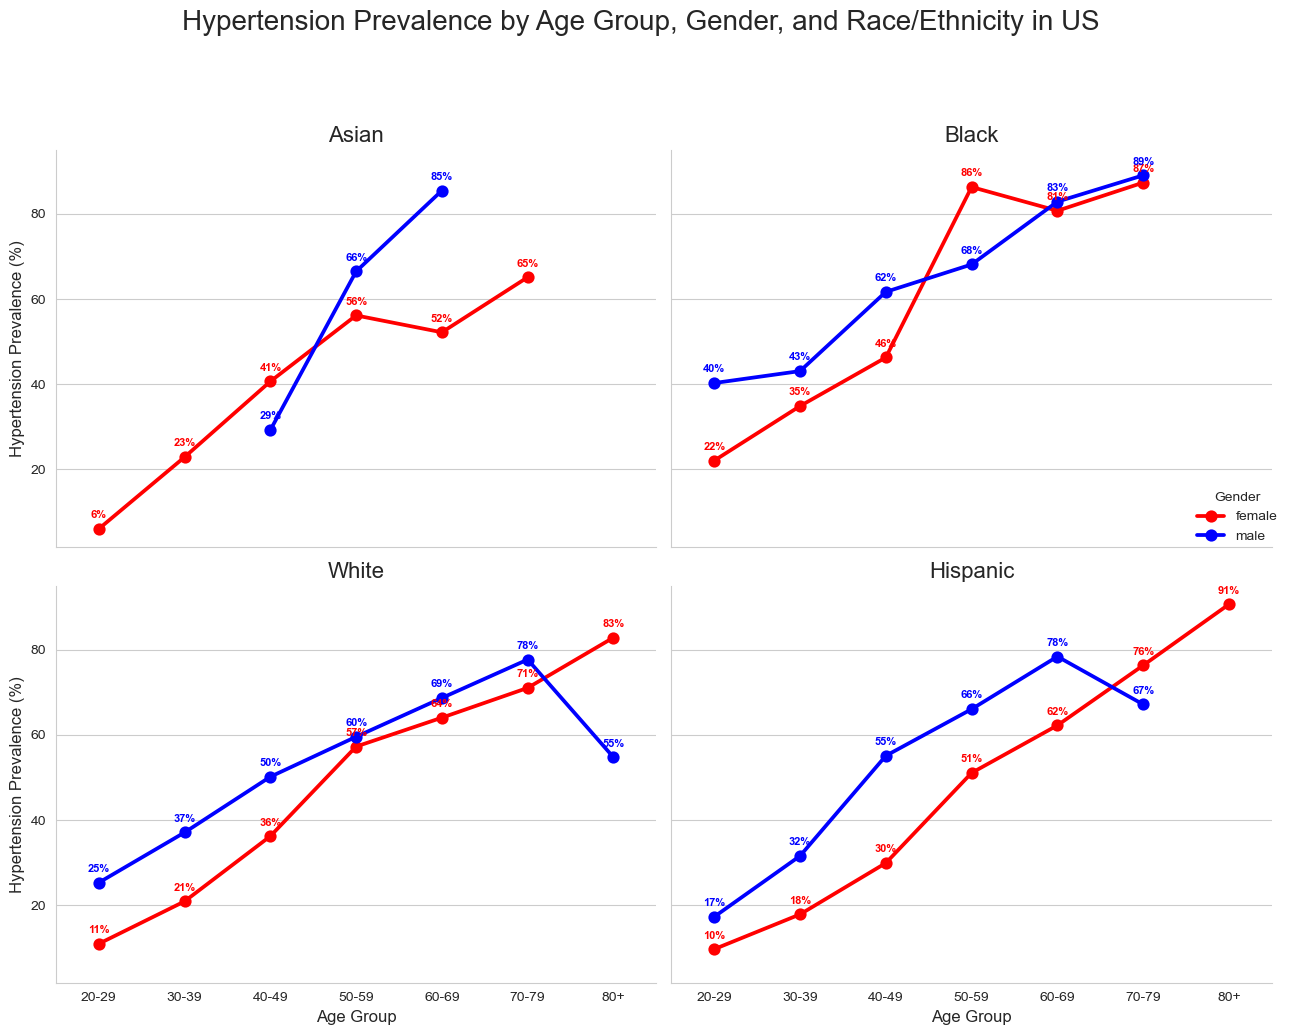

In [99]:
# ==============================================================================
# Part 6: Visualization 
# ==============================================================================
# --- Create plotting order ---
new_race_order = [
    'Asian', 
    'Black', 
    'White', 
    'Hispanic'
]

# cast 'Race_Ethnicity_Label' into ordinal categorical
reliable_results['Race_Ethnicity_Label'] = pd.Categorical(
    reliable_results['Race_Ethnicity_Label'], 
    categories=new_race_order, 
    ordered=True
)
reliable_results.sort_values(by=['Race_Ethnicity_Label', 'Gender', 'Age_Group'], inplace=True)

# --- Plotting ---
g = sns.catplot(
    data=reliable_results,
    x='Age_Group',
    y='Prevalence (%)',
    hue='Gender',
    col='Race_Ethnicity_Label',
    col_order=new_race_order, 
    kind='point',
    col_wrap=2, # 2 x 2 graph
    height=5,
    aspect=1.2,
    palette={'male': 'blue', 'female': 'red'}
)

# --- Add Text Labels to Each Point ---
for ax in g.axes.flat:
    for line in ax.get_lines():
        x_data, y_data = line.get_xdata(), line.get_ydata()
        color = line.get_color()
        for x, y in zip(x_data, y_data):
            if not np.isnan(y):
                ax.text(x, y + 2.5, f"{y:.0f}%", ha='center', size=8, color=color, weight='semibold')

# --- Finalize titles and layout ---
g.fig.suptitle('Hypertension Prevalence by Age Group, Gender, and Race/Ethnicity in US', y=1.03, size=20)
g.set_axis_labels("Age Group", "Hypertension Prevalence (%)")
g.set_titles("{col_name}", size=16)
g.legend.set_title("Gender")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

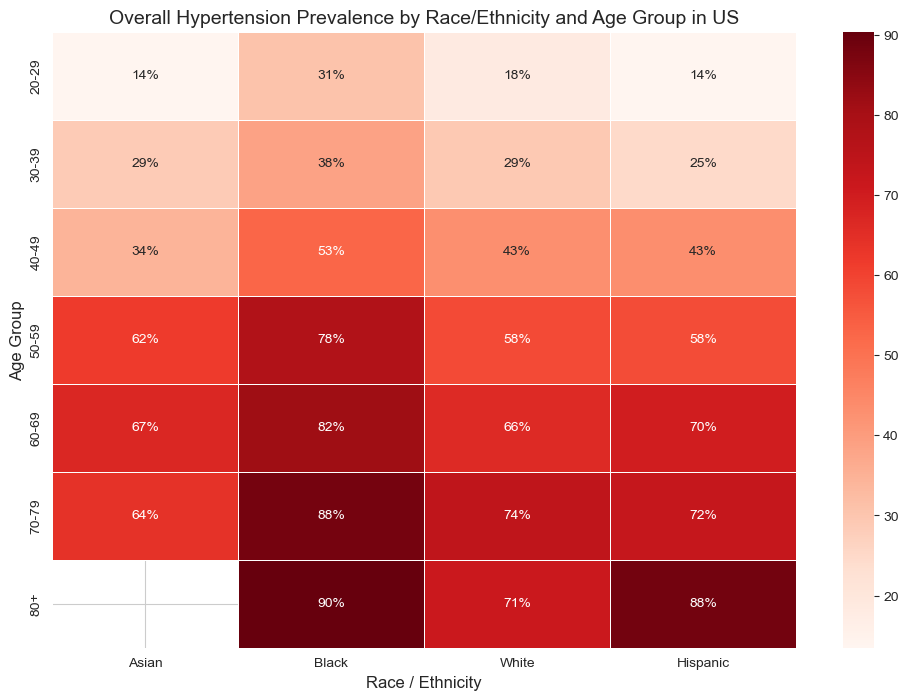

In [86]:
# ==============================================================================
# Part 6: Visualization - Heatmap
# ==============================================================================

# --- calc hypertension risk by age and race ---
race_age_prevalence = df_adults.groupby(
    ['Race_Ethnicity_Label', 'Age_Group'],
    observed=True
).apply(compute_prevalence_and_samplesize).reset_index()

reliable_race_age = race_age_prevalence[race_age_prevalence['Unweighted_Sample_Size'] >= 30].copy()


overall_pivot = reliable_race_age.pivot_table(
    values='Prevalence (%)',
    index='Age_Group',
    columns='Race_Ethnicity_Label',
    observed=True
)
overall_pivot = overall_pivot.reindex(columns=new_race_order) 

# --- Add annotation ---
overall_pivot_annot = overall_pivot.fillna(0).applymap(lambda x: f"{x:.0f}%" if x > 0 else "")

# --- Plotting Heatmap ---
plt.figure(figsize=(12, 8)) 
sns.heatmap(
    overall_pivot,
    annot=overall_pivot_annot,
    fmt="",
    linewidths=.5,
    cmap="Reds",
    annot_kws={"size": 10}
)
plt.title("Overall Hypertension Prevalence by Race/Ethnicity and Age Group in US", fontsize=14)
plt.xlabel("Race / Ethnicity", fontsize=12)
plt.ylabel("Age Group", fontsize=12)
plt.show()

# (2) Verify Hypothesis: BMI and Abdominal Obesity correlate strongly with hypertension risk.
## 2.1 BMI vs. Hypertension

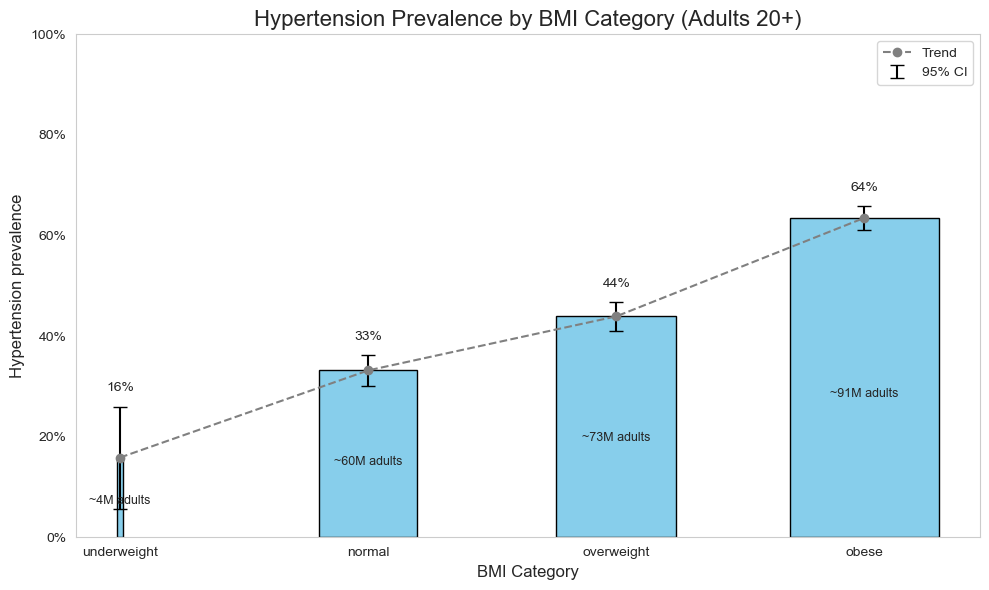

In [87]:
# --- EDA and Visualization: BMI Category vs Hypertension (Adults 20+) ---

# Keep rows for adults 20+, those with hypertension, BMI classification, and weight.
df_bmi_filtered = df_adults[(df_adults['Age_Years'] >= 20) & df_adults['Hypertensive'].notna() & df_adults['BMI_Category'].notna() & (df_adults['Exam_Weight'] > 0)]

# Calculate weighted prevalence
def compute_weighted_ci(group):
    weights = group['Exam_Weight']
    p = np.average(group['Hypertensive'], weights=weights)

    weight_sum = weights.sum()
    weight_sq_sum = (weights**2).sum()
    n_eff = (weight_sum ** 2) / weight_sq_sum

    se = np.sqrt(p * (1 - p) / n_eff)
    ci_lower = max(0, p - 1.96 * se)
    ci_upper = min(1, p + 1.96 * se)
    
    return pd.Series({
        'Weighted_Hypertension_Prevalence': p,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Weighted_Population': weight_sum
    })

bmi_results = df_bmi_filtered.groupby("BMI_Category").apply(compute_weighted_ci).reset_index()

# --- revise order for BMI category ---
bmi_order = ['underweight', 'normal', 'overweight', 'obese']
bmi_results['BMI_Category'] = pd.Categorical(bmi_results['BMI_Category'], categories=bmi_order, ordered=True)
bmi_results = bmi_results.sort_values('BMI_Category').reset_index(drop=True)

# --- Bar width represents US adult population ---
bmi_results['Norm_Pop'] = bmi_results['Weighted_Population'] / bmi_results['Weighted_Population'].max() #  let the audience to feel the difference between the largest group and other groups.
 # More intuitively reflect the proportional differences (who is particularly large, and who is particularly small)


# --- visulization ---
plt.figure(figsize=(10, 6))
bar_positions = np.arange(len(bmi_results))

bars = plt.bar(
    bar_positions,
    bmi_results['Weighted_Hypertension_Prevalence'],
    width=bmi_results['Norm_Pop'] * 0.6,
    color='skyblue',
    edgecolor='black'
)

# add error bar 
plt.errorbar(
    x=bar_positions,
    y=bmi_results['Weighted_Hypertension_Prevalence'],
    yerr=[
        bmi_results['Weighted_Hypertension_Prevalence'] - bmi_results['CI_Lower'],
        bmi_results['CI_Upper'] - bmi_results['Weighted_Hypertension_Prevalence']
    ],
    fmt='none', ecolor='black', capsize=5, label="95% CI"
)

# labeling
for i, row in bmi_results.iterrows():
    percent = int(round(row['Weighted_Hypertension_Prevalence'] * 100))
    pop_m = int(round(row['Weighted_Population'] / 1_000_000))
    
    # label population size 
    plt.text(i, row['Weighted_Hypertension_Prevalence'] * 0.45,
             f"~{pop_m}M adults", ha='center', va='center', fontsize=9)
    
    # hypertension rate on top of bars
    plt.text(i, row['CI_Upper'] + 0.03,
             f"{percent}%", ha='center', fontsize=10)

# add trendline
plt.plot(bar_positions, bmi_results['Weighted_Hypertension_Prevalence'],
         marker='o', linestyle='--', color='gray', label='Trend')

# set up 
plt.xticks(bar_positions, bmi_results['BMI_Category'])
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.title("Hypertension Prevalence by BMI Category (Adults 20+)")
plt.xlabel("BMI Category")
plt.ylabel("Hypertension prevalence")
plt.ylim(0, 1)

# remove gridlines
plt.grid(False)
plt.legend()
plt.tight_layout()

# save pic
plt.savefig("../visualization/hypertension_by_BMI_category_US_adults.png", dpi=300, bbox_inches='tight')

plt.show()
    # Bar heights represent hypertension prevalence.
    # Bar widths represent normalized population proportions.

# --- Save output for Tableau ---
# bmi_results.to_csv("../output/hypertension_by_BMI_category_US_adults.csv", index=False)


## 2.2 Abdominal Obesity vs. Hypertension

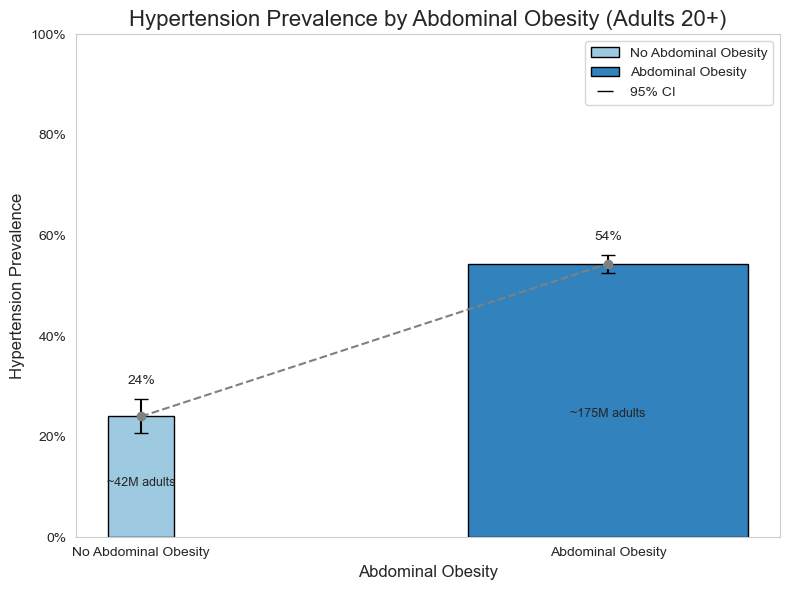

In [88]:
# --- Visualization: Abdominal Obesity vs Hypertension (Adults 20+) ---

# Keep rows for adults 20+, those with hypertension, Abdominal_Obesity, and weight.
df_abo_filtered = df_adults[(df_adults["Age_Years"] >= 20) & df_adults["Hypertensive"].notna() & df_adults["Abdominal_Obesity"].notna() & (df_adults["Exam_Weight"] > 0)].copy() # use .copy() to avoid SettingWithCopyWarning

abd_results = df_abo_filtered.groupby("Abdominal_Obesity").apply(compute_weighted_ci).reset_index()
abd_results['Label'] = abd_results['Abdominal_Obesity'].map({True: "Abdominal Obesity", False: "No Abdominal Obesity"})

# --- Normalize width for visual scaling ---
abd_results['Norm_Pop'] = abd_results['Weighted_Population'] / abd_results['Weighted_Population'].max()

# --- Plotting ---
plt.figure(figsize=(8, 6))
bar_positions = np.arange(len(abd_results))

# Custom colors
colors = ['#9ecae1', '#3182bd']
bars = plt.bar(
    bar_positions,
    abd_results['Weighted_Hypertension_Prevalence'],
    width=abd_results['Norm_Pop'] * 0.6,
    color=colors,
    edgecolor='black'
)

# Error bars
plt.errorbar(
    x=bar_positions,
    y=abd_results['Weighted_Hypertension_Prevalence'],
    yerr=[
        abd_results['Weighted_Hypertension_Prevalence'] - abd_results['CI_Lower'],
        abd_results['CI_Upper'] - abd_results['Weighted_Hypertension_Prevalence']
    ],
    fmt='none', ecolor='black', capsize=5, label="95% CI"
)

# Labels
for i, row in abd_results.iterrows():
    percent = int(round(row['Weighted_Hypertension_Prevalence'] * 100))
    pop_m = int(round(row['Weighted_Population'] / 1_000_000))

    plt.text(i, row['Weighted_Hypertension_Prevalence'] * 0.45,
             f"~{pop_m}M adults", ha='center', va='center', fontsize=9)
    plt.text(i, row['CI_Upper'] + 0.03,
             f"{percent}%", ha='center', fontsize=10)
    
# Trend line
plt.plot(bar_positions, abd_results['Weighted_Hypertension_Prevalence'],
         marker='o', linestyle='--', color='gray', label='Trend')

# Setup
plt.xticks(bar_positions, abd_results['Label'])
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.title("Hypertension Prevalence by Abdominal Obesity (Adults 20+)")
plt.ylabel("Hypertension Prevalence")
plt.xlabel("Abdominal Obesity")
plt.ylim(0, 1)
plt.grid(False)

# Legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=colors[0], edgecolor='black', label="No Abdominal Obesity"),
    Patch(facecolor=colors[1], edgecolor='black', label="Abdominal Obesity"),
    plt.Line2D([0], [0], color='black', linestyle='none', marker='_', markersize=12, label='95% CI')
]
plt.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()

# --- Step 6: Export table for Tableau ---
# abd_results.to_csv("../output/hypertension_by_abdominal_obesity_US_adults.csv", index=False)

## 2.3 BMI + Abdominal Obesity vs. Hypertension

BMI_Category value counts:
BMI_Category
obese          2158
overweight     1722
normal         1364
underweight      69
Name: count, dtype: int64

----------------------------------------

Abdominal_Obesity value counts::
Abdominal_Obesity
True     4415
False     898
Name: count, dtype: int64


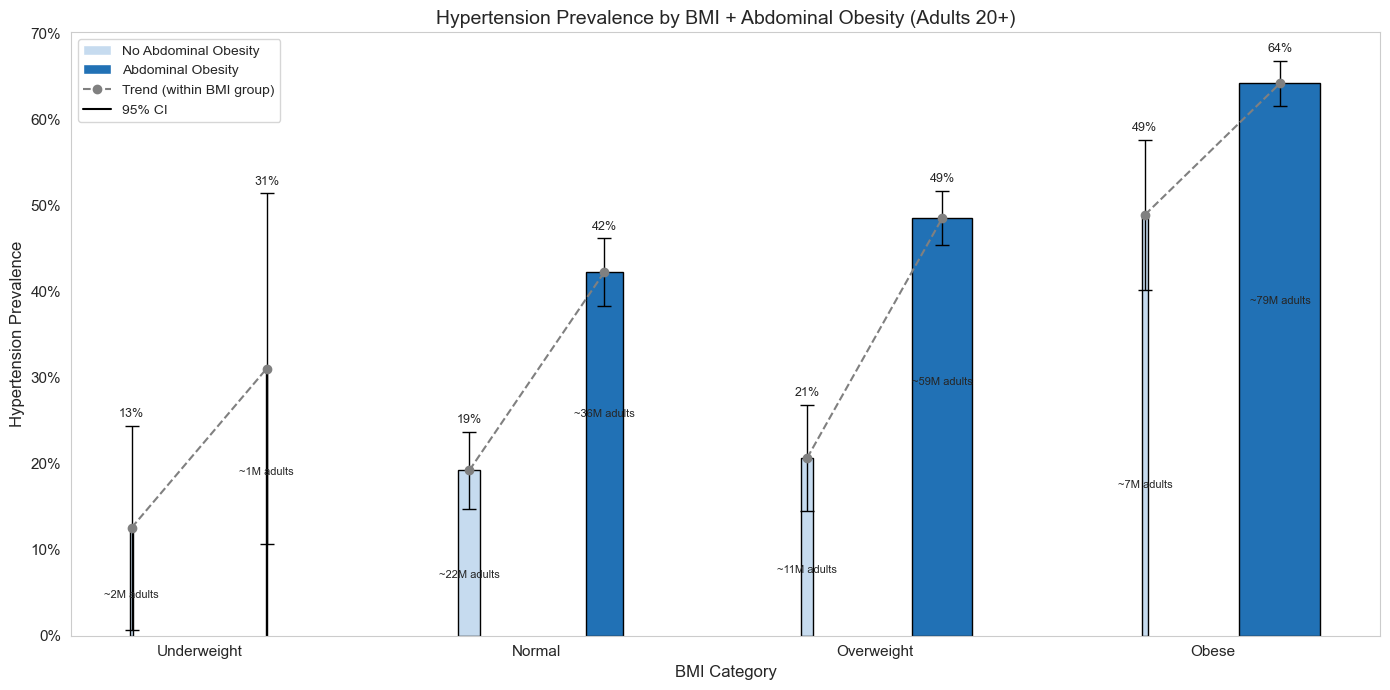

In [89]:
# --- Visualization: BMI + Abdominal Obesity vs Hypertension (Adults 20+) ---

df_bmi_abo_filtered = df_adults[(df_adults['Age_Years'] >= 20) & df_adults['Hypertensive'].notna() & df_adults['BMI_Category'].notna() & df_adults['Abdominal_Obesity'].notna() & (df_adults['Exam_Weight'] > 0)].copy()

# Get value counts of BMI categories & Abdominal obesity (incl. NaN)
bmi_counts = df_bmi_abo_filtered['BMI_Category'].value_counts(dropna=False)
abdominal_counts = df_bmi_abo_filtered['Abdominal_Obesity'].value_counts(dropna=False)

# print outputs 
print("BMI_Category value counts:")
print(bmi_counts)

print("\n" + "-"*40 + "\n")
print("Abdominal_Obesity value counts::")
print(abdominal_counts)
# Capitalize BMI category for better visualization
df_bmi_abo_filtered['BMI_Category'] = df_bmi_abo_filtered['BMI_Category'].str.capitalize()

# Create a combined group for analysis
df_bmi_abo_filtered['BMI_Ab_Group'] = (
    df_bmi_abo_filtered['BMI_Category'].astype(str) + ' + ' + 
    df_bmi_abo_filtered['Abdominal_Obesity'].map({True: 'AbOb+', False: 'AbOb-'})
)

# Apply the calculation to each group
combo_results = df_bmi_abo_filtered.groupby("BMI_Ab_Group").apply(compute_weighted_ci).reset_index()


# --- Prepare the results data for plotting ---
# Split the combined group back into separate columns for ordering
combo_results[['BMI_Category', 'AbOb_Status']] = combo_results['BMI_Ab_Group'].str.split(' \+ ', expand=True)

# Define a logical order for categories
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese']
abob_order = ['AbOb-', 'AbOb+']

# Apply the categorical ordering
combo_results['BMI_Category'] = pd.Categorical(combo_results['BMI_Category'], categories=bmi_order, ordered=True)
combo_results['AbOb_Status'] = pd.Categorical(combo_results['AbOb_Status'], categories=abob_order, ordered=True)
combo_results = combo_results.sort_values(['BMI_Category', 'AbOb_Status']).reset_index(drop=True)

# Normalize population for variable bar widths
combo_results['Norm_Pop'] = combo_results['Weighted_Population'] / combo_results['Weighted_Population'].max()


# --- Visualization - Custom Grouped and Scaled Bar Chart ---
# Set colors and figure size
color_map = {'AbOb-': '#c6dbef', 'AbOb+': '#2171b5'}
plt.figure(figsize=(14, 7))

# Manually calculate bar positions for grouping
bar_positions = []
x_tick_positions = []
x_tick_labels = []
x = 0
group_spacing = 0.5  # Space between each BMI category group

for bmi in bmi_order:
    group_df = combo_results[combo_results['BMI_Category'] == bmi]
    if group_df.empty: continue

    # Store positions for bars within the group
    group_bar_positions = []
    for _ in range(len(group_df)):
        group_bar_positions.append(x)
        x += 1
    
    bar_positions.extend(group_bar_positions)
    
    # Store center position for the group label
    if group_bar_positions:
        x_tick_positions.append(np.mean(group_bar_positions))
        x_tick_labels.append(bmi)
    
    x += group_spacing

# Plot bars with variable widths
plt.bar(
    bar_positions,
    combo_results['Weighted_Hypertension_Prevalence'],
    width=combo_results['Norm_Pop'] * 0.6,  # Scale width by normalized population
    color=[color_map[ab_stat] for ab_stat in combo_results['AbOb_Status']],
    edgecolor='black'
)

# Add error bars
plt.errorbar(
    bar_positions,
    combo_results['Weighted_Hypertension_Prevalence'],
    yerr=[
        combo_results['Weighted_Hypertension_Prevalence'] - combo_results['CI_Lower'],
        combo_results['CI_Upper'] - combo_results['Weighted_Hypertension_Prevalence']
    ],
    fmt='none',
    ecolor='black',
    capsize=5,
    linewidth=1
)

# Add trend lines within each BMI group
for bmi_cat in bmi_order:
    group_data = combo_results[combo_results['BMI_Category'] == bmi_cat]
    if len(group_data) > 1:
        # Get the specific x-positions for this group's bars
        current_bar_indices = group_data.index.tolist()
        current_x_positions = [bar_positions[i] for i in current_bar_indices]
        plt.plot(
            current_x_positions,
            group_data['Weighted_Hypertension_Prevalence'],
            color='gray',
            linestyle='--',
            marker='o'
        )

# Add text labels for percentages and population
for i, row in combo_results.iterrows():
    is_right_bar = (i % 2 == 1)
    
    # Percentage label
    plt.text(bar_positions[i], row['CI_Upper'] + 0.01,
             f"{int(round(row['Weighted_Hypertension_Prevalence'] * 100))}%",
             ha='center', fontsize=9)

    # Population label (with vertical offset)
    pop_m = row['Weighted_Population'] / 1_000_000
    pop_y = (row['Weighted_Hypertension_Prevalence'] * 0.6 if is_right_bar else row['Weighted_Hypertension_Prevalence'] * 0.35)
    plt.text(bar_positions[i], pop_y, f"~{int(round(pop_m))}M adults",
             ha='center', fontsize=8)

# --- Finalize plot aesthetics ---
plt.xticks(x_tick_positions, x_tick_labels, fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel("Hypertension Prevalence", fontsize=12)
plt.xlabel("BMI Category", fontsize=12)
# plt.ylim(0, 1)
plt.title("Hypertension Prevalence by BMI + Abdominal Obesity (Adults 20+)", fontsize=14)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.grid(False)

# Custom legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor=color_map['AbOb-'], label='No Abdominal Obesity'),
    Patch(facecolor=color_map['AbOb+'], label='Abdominal Obesity'),
    Line2D([0], [0], color='gray', linestyle='--', marker='o', label='Trend (within BMI group)'),
    Line2D([0], [0], color='black', linestyle='-', label='95% CI')
]
plt.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

# (3) Understand lifestyle factors: what correlate strongly with hypertension risk?
## 3.1 Smoking vs. Hypertension

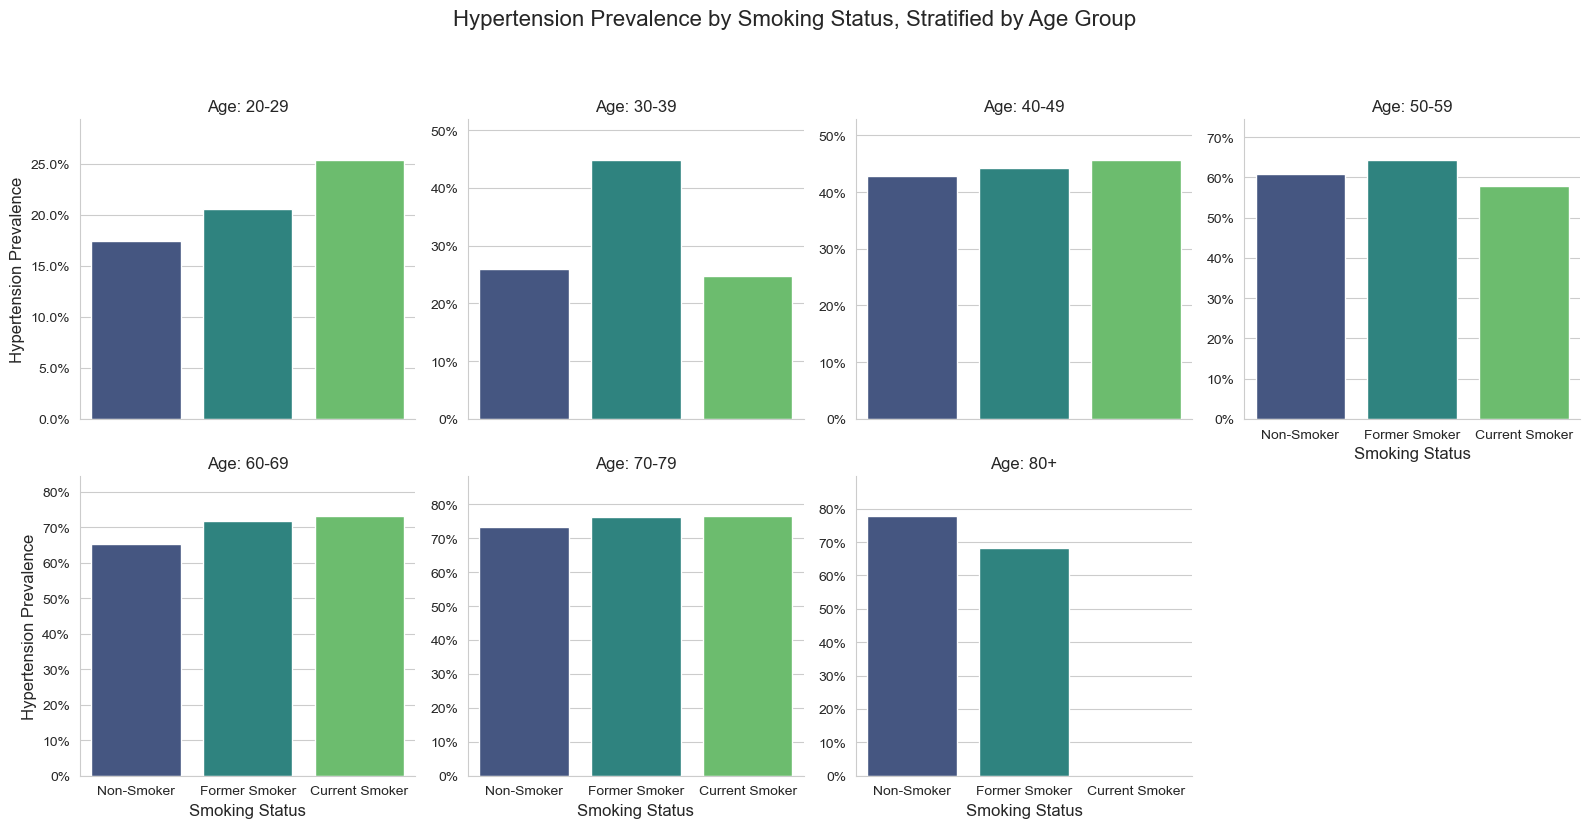

In [90]:
# ==============================================================================
# Part 1: Feature Engineering for Smoking Status
# ==============================================================================
# This section creates the 'Smoking_Status' categorical variable.

def classify_smoker(row):
    """Categorizes participants into Non-smoker, Former Smoker, or Current Smoker."""
    smokes_now = row.get('Smokes_Now')
    smoked_lifetime = row.get('Smoked_100_Cigs_Lifetime')

    if smokes_now in [1, 2]:
        return 'Current Smoker'
    elif smokes_now == 3:
        if smoked_lifetime == 1:
            return 'Former Smoker'
        elif smoked_lifetime == 2:
            return 'Non-Smoker'
    if smoked_lifetime == 1:
        return 'Former Smoker'
    elif smoked_lifetime == 2:
        return 'Non-Smoker'
    return 'Unknown'

# Apply the function to the main adults dataframe
if 'Smoking_Status' not in df_adults.columns:
    df_adults['Smoking_Status'] = df_adults.apply(classify_smoker, axis=1)

# ==============================================================================
# Part 2: Stratified Analysis by Age Group
# ==============================================================================
# This analysis controls for the confounding effect of age by stratifying the data.

# --- Step 2.1: Prepare data for stratified analysis ---
# Filter out unknown smoking status and ensure necessary columns are present
df_stratified = df_adults[
    (df_adults['Smoking_Status'] != 'Unknown') &
    (df_adults['Age_Group'].notna()) &
    (df_adults['Hypertensive_numeric'].notna()) &
    (df_adults['Exam_Weight'] > 0)
].copy()

# --- Step 2.2: Define the CI calculation function ---
def compute_prevalence_with_ci(group):
    """Calculates weighted prevalence and 95% CI for a given group."""
    weights = group['Exam_Weight']
    p = np.average(group['Hypertensive_numeric'], weights=weights)
    
    weight_sum = weights.sum()
    weight_sq_sum = (weights**2).sum()
    n_eff = (weight_sum**2) / weight_sq_sum if weight_sq_sum > 0 else 0
    se = np.sqrt(p * (1 - p) / n_eff) if n_eff > 0 else 0
    
    ci_lower = max(0, p - 1.96 * se)
    ci_upper = min(1, p + 1.96 * se)
    
    return pd.Series({
        'Prevalence': p,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'SampleSize': len(group)
    })

# --- Step 2.3: Group by Age and Smoking Status and calculate prevalence ---
stratified_results = df_stratified.groupby(['Age_Group', 'Smoking_Status'], observed=True).apply(compute_prevalence_with_ci).reset_index()

# Filter out groups with a small sample size for more reliable results
stratified_results_reliable = stratified_results[stratified_results['SampleSize'] >= 25].copy()


# ==============================================================================
# Part 3: Stratified Visualization
# ==============================================================================
# This faceted plot shows the relationship within each age group.

# Define a logical order for the x-axis
smoking_order = ['Non-Smoker', 'Former Smoker', 'Current Smoker']

g = sns.catplot(
    data=stratified_results_reliable,
    x='Smoking_Status',
    y='Prevalence',
    col='Age_Group',
    kind='bar',
    col_wrap=4,
    height=4,
    aspect=1,
    order=smoking_order,
    palette='viridis',
    errorbar=None,
    sharey=False # Allow each facet to have its own y-axis scale
)

# --- Add Custom Error Bars and Labels ---
for ax in g.axes.flat:
    # Get the specific subset of data for the current subplot (facet)
    age_group = ax.get_title().split(' = ')[1]
    sub_data = stratified_results_reliable[stratified_results_reliable['Age_Group'] == age_group]
    
    # Create an ordered list of x positions for the error bars
    x_coords = [s for s in smoking_order if s in sub_data['Smoking_Status'].values]
    
    # # # Add error bars
    # # yerr = [
    # #     sub_data['Prevalence'] - sub_data['CI_Lower'],
    # #     sub_data['CI_Upper'] - sub_data['Prevalence']
    # # ]
    # # ax.errorbar(
    # #     x=x_coords,
    # #     y=sub_data['Prevalence'],
    # #     yerr=yerr,
    # #     fmt='none',
    # #     capsize=4,
    # #     ecolor='black'
    # # )
    
    # # Add percentage labels
    # for i, row in sub_data.iterrows():
    #     x_pos = x_coords.index(row['Smoking_Status'])
    #     ax.text(
    #         x_pos,
    #         row['CI_Upper'] + 0.02, # Position above the error bar
    #         f"{row['Prevalence'] * 100:.0f}%",
    #         ha='center',
    #         fontsize=9
    #     )

# --- Finalize plot aesthetics ---
g.fig.suptitle("Hypertension Prevalence by Smoking Status, Stratified by Age Group", y=1.03, fontsize=16)
g.set_axis_labels("Smoking Status", "Hypertension Prevalence")
g.set_titles("Age: {col_name}")
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1) # Add a little space at the top

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

❗️To isolate and quantify the true, independent effect of a single risk factor, we must use a statistical model because simple analysis cannot control for multiple confounding variables like age, BMI, and gender simultaneously.

## 3.2 Smoking + Alcohol vs. Hypertension
### Multivariable Logistic Regression Modelling: When age, gender, race, BMI category, and abdominal obesity are controlled for, do a person's drinking or smoking habits still affect their risk of hypertension?

In [91]:
# ==============================================================================
# Part 1: Feature Engineering for Smoking and Alcohol
# ==============================================================================
# This section creates categorical variables for smoking and alcohol habits.

# --- 1.1: Create Smoking Status Category ---
def classify_smoker(row):
    """Categorizes participants into Non-smoker, Former Smoker, or Current Smoker."""
    smokes_now = row.get('Smokes_Now')
    smoked_lifetime = row.get('Smoked_100_Cigs_Lifetime')

    if smokes_now in [1, 2]:
        return 'Current Smoker'
    elif smokes_now == 3:
        if smoked_lifetime == 1:
            return 'Former Smoker'
        elif smoked_lifetime == 2:
            return 'Non-Smoker'
    if smoked_lifetime == 1:
        return 'Former Smoker'
    elif smoked_lifetime == 2:
        return 'Non-Smoker'
    return 'Unknown'

df_adults['Smoking_Status'] = df_adults.apply(classify_smoker, axis=1)


# --- 1.2: Create Alcohol Consumption Level Category ---
def classify_drinker(row):
    """Categorizes participants into Non-drinker, Moderate Drinker, or Heavy Drinker."""
    avg_drinks = row.get('Avg_Drinks_Per_Drinking_Day')
    freq = row.get('Drinking_Frequency')
    gender = row.get('Gender')

    if pd.isna(freq) or freq == 0:
        return 'Non-drinker'
    if pd.isna(avg_drinks):
        return 'Unknown'
    
    if gender == 'male':
        return 'Heavy Drinker' if avg_drinks > 2 else 'Moderate Drinker'
    elif gender == 'female':
        return 'Heavy Drinker' if avg_drinks > 1 else 'Moderate Drinker'
    
    return 'Unknown'

df_adults['Alcohol_Level'] = df_adults.apply(classify_drinker, axis=1)


# ==============================================================================
# Part 2: Prepare Data for Regression Modeling
# ==============================================================================
import statsmodels.api as sm

# --- 2.1: Select variables for the model ---
model_cols = [
    'Hypertensive_numeric', 'Age_Years', 'Gender', 'Race_Ethnicity_Label',
    'BMI_Category', 'Abdominal_Obesity', 'Smoking_Status', 'Alcohol_Level'
]

# Create a modeling dataframe, dropping rows with missing or unwanted values
df_model = df_adults[model_cols].dropna().copy()
df_model = df_model[~df_model['Smoking_Status'].isin(['Unknown'])]
df_model = df_model[~df_model['Alcohol_Level'].isin(['Unknown'])]
df_model = df_model[~df_model['BMI_Category'].isin(['underweight'])]

print(f"Number of participants in the final model: {len(df_model)}")

# --- 2.2: Create Dummy Variables ---
df_dummies = pd.get_dummies(
    df_model, 
    columns=['Gender', 'Race_Ethnicity_Label', 'BMI_Category', 'Abdominal_Obesity', 'Smoking_Status', 'Alcohol_Level'],
    drop_first=True
)


# ==============================================================================
# Part 3: Build, Run, and Summarize the Logistic Regression Model
# ==============================================================================

# --- 3.1: Define Dependent (y) and Independent (X) variables ---
y = df_dummies['Hypertensive_numeric']
X = df_dummies.drop('Hypertensive_numeric', axis=1)
X = sm.add_constant(X)

# --- 3.2: Build and Fit the Model ---
logit_model = sm.Logit(y, X.astype(float))
result = logit_model.fit(disp=0) # disp=0 suppresses the optimization output

# --- 3.3: Print the Summary ---
# This command generates the statistical summary table
print("\n" + "="*80)
print("Logistic Regression Model Summary")
print("="*80)
print(result.summary())

Number of participants in the final model: 5226

Logistic Regression Model Summary
                            Logit Regression Results                            
Dep. Variable:     Hypertensive_numeric   No. Observations:                 5226
Model:                            Logit   Df Residuals:                     5213
Method:                             MLE   Df Model:                           12
Date:                  Mon, 16 Jun 2025   Pseudo R-squ.:                  0.1653
Time:                          18:43:04   Log-Likelihood:                -3001.2
converged:                         True   LL-Null:                       -3595.5
Covariance Type:              nonrobust   LLR p-value:                5.259e-247
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -3.3061      0.202    -16.368      0.

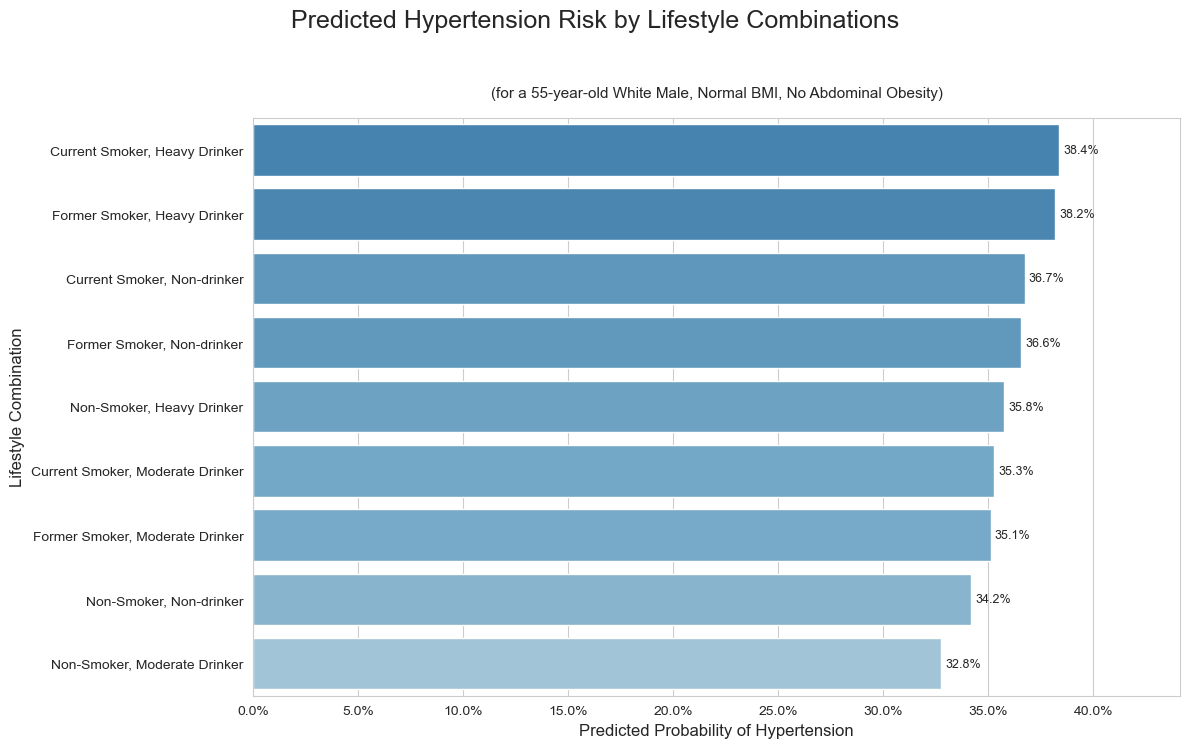

In [92]:
# ==============================================================================
# Part 4: Visualize Predicted Probabilities for Combinations
# ==============================================================================
# This cell uses the trained model ('result') from the previous cell to generate
# an intuitive visualization of combined lifestyle risks.

from matplotlib import cm
from matplotlib.colors import Normalize

# --- 4.1: Define a base profile for our example person ---
# This dictionary represents a baseline person. The keys MUST exactly match the
# column names in the model's X DataFrame.
# Baseline: 55-y/o White Male, Normal BMI, No Abdominal Obesity, Current Smoker, Heavy Drinker.
base_profile = {col: 0.0 for col in X.columns}
base_profile.update({
    'const': 1.0, 
    'Age_Years': 55.0, 
    'Gender_male': 1.0,
    'Race_Ethnicity_Label_White': 1.0, 
    'BMI_Category_Normal': 1.0,
})

# --- 4.2: Define the lifestyle combinations (scenarios) to test ---
# Each dictionary specifies which dummy variables to "turn on" (set to 1.0)
scenarios = {
    "Current Smoker, Heavy Drinker":    {},
    "Current Smoker, Moderate Drinker": {"Alcohol_Level_Moderate Drinker": 1.0},
    "Current Smoker, Non-drinker":      {"Alcohol_Level_Non-drinker": 1.0},
    "Former Smoker, Heavy Drinker":     {"Smoking_Status_Former Smoker": 1.0},
    "Former Smoker, Moderate Drinker":  {"Smoking_Status_Former Smoker": 1.0, "Alcohol_Level_Moderate Drinker": 1.0},
    "Former Smoker, Non-drinker":       {"Smoking_Status_Former Smoker": 1.0, "Alcohol_Level_Non-drinker": 1.0},
    "Non-Smoker, Heavy Drinker":        {"Smoking_Status_Non-Smoker": 1.0},
    "Non-Smoker, Moderate Drinker":     {"Smoking_Status_Non-Smoker": 1.0, "Alcohol_Level_Moderate Drinker": 1.0},
    "Non-Smoker, Non-drinker":          {"Smoking_Status_Non-Smoker": 1.0, "Alcohol_Level_Non-drinker": 1.0},
}

# --- 4.3: Calculate the predicted probability for each combination ---
predictions = {}
for name, lifestyle_update in scenarios.items():
    current_profile_dict = base_profile.copy()
    current_profile_dict.update(lifestyle_update)
    scenario_df = pd.DataFrame([current_profile_dict])[X.columns]
    pred_prob = result.predict(scenario_df.astype(float))[0]
    predictions[name] = pred_prob

# --- 4.4: Create the final combination visualization with aesthetic updates ---
pred_df = pd.DataFrame(list(predictions.items()), columns=['Scenario', 'Predicted_Probability'])
# Sort descending to place highest risk on top
pred_df = pred_df.sort_values('Predicted_Probability', ascending=False) 

# Create a softer color gradient
cmap = cm.get_cmap('Blues')
# Set vmin and vmax to control the color range, making it lighter overall
norm = Normalize(vmin=0.25, vmax=0.45) 
bar_colors = [cmap(norm(value)) for value in pred_df['Predicted_Probability']]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=pred_df,
    x='Predicted_Probability',
    y='Scenario',
    palette=bar_colors, # Apply the custom gradient palette
    ax=ax
)

# Add titles with different font sizes
fig.suptitle(
    "Predicted Hypertension Risk by Lifestyle Combinations",
    fontsize=18, y=0.96
)
ax.set_title(
    "(for a 55-year-old White Male, Normal BMI, No Abdominal Obesity)",
    fontsize=11, pad=15 # Smaller font for the subtitle
)

# Add labels and formatting
ax.set_xlabel('Predicted Probability of Hypertension', fontsize=12)
ax.set_ylabel('Lifestyle Combination', fontsize=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Add data labels to the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + 0.002, 
        p.get_y() + p.get_height() / 2,
        f'{width:.1%}',
        va='center', ha='left', fontsize=9
    )

ax.set_xlim(0, max(pred_df['Predicted_Probability']) * 1.15)
plt.tight_layout(rect=[0, 0.03, 1, 0.93]) # Adjust layout to prevent title overlap
plt.show()



The risk for Non-smokers and Non-drinkers is 34.2%, while the risk for Non-smokers and Moderate Drinkers is 32.8%. This phenomenon is classic in epidemiological studies and is usually referred to as the 'J-shaped curve' effect. This does not mean that moderate drinking is healthier than complete abstinence. The most likely explanation is that, although our model controls for many variables, it still cannot fully capture the 'Healthy User Bias' and some unmeasured confounding factors.

In [98]:
# comparing results 
# Calculate the weighted actual prevalence for the subset of the profile.
subset = df_adults[
    (df_adults['Age_Years'] == 55) &
    (df_adults['Gender'] == 'male') &
    (df_adults['Race_Ethnicity'] == 3.0) # white
]

result = compute_weighted_ci(subset) 
actual = result['Weighted_Hypertension_Prevalence']
print(f"Weighted actual prevalence for the profile: {actual:.1%}")


Weighted actual prevalence for the profile: 51.0%


### Crude vs. Adjusted Hypertension Prevalence

### Crude Prevalence (51%)

The general population is a mixed group — a "melting pot" that includes:
- Individuals with normal BMI, overweight, and obesity
- Those with and without abdominal obesity
- Both smokers and non-smokers

As a result, the **51% prevalence** represents a **crude average** across this diverse population.  
Because this population includes many high-risk individuals (e.g., overweight/obese), the average prevalence is **naturally elevated**.

---

### Adjusted Predicted Probability (38%)

The model-predicted **38% probability** refers to a **specific, idealized profile**:
- A 55-year-old non-Hispanic White male  
- With **normal BMI**  
- And **no abdominal obesity**

This is a **healthier-than-average profile**.  
The logistic regression model has **adjusted for the extra risks** associated with BMI and abdominal obesity.

Therefore, the 38% value reflects the **adjusted predicted probability** for someone who does **not** carry these additional risk factors — **not** a crude average across the population.
